Week 14 · Day 3 — Evaluation & Error Analysis
Why this matters

Fine-tuned models aren’t useful unless we can trust and measure them. Today you’ll learn to go beyond accuracy and dig into precision, recall, F1, and confusion matrices — and spot where the model fails.

Theory Essentials

Accuracy = % correct predictions; can be misleading with class imbalance.

Precision = of predicted positives, how many are correct.

Recall = of actual positives, how many did we catch.

F1 = harmonic mean of precision and recall.

Confusion Matrix = shows per-class errors.

Error analysis = manually check misclassified examples to find patterns.

In [1]:
# Setup
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Load dataset (IMDB)
dataset = load_dataset("imdb")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

tokenized = dataset.map(tokenize, batched=True)

# Keep only needed columns
tokenized = tokenized.remove_columns(["text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch")

# Small subset for speed (optional)
small_train = tokenized["train"].shuffle(seed=42).select(range(500))
small_test = tokenized["test"].shuffle(seed=42).select(range(200))

# Load model
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

# Training
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    logging_dir="./logs",
    logging_steps=50,
    save_steps=5000,         # big number → disables frequent saving
    save_total_limit=1
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    compute_metrics=compute_metrics,
)

trainer.train()
metrics = trainer.evaluate()
print(metrics)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\AI-Mastery\venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
50,0.629700


c:\AI-Mastery\venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.487712562084198, 'eval_accuracy': 0.785, 'eval_precision': 0.7731958762886598, 'eval_recall': 0.78125, 'eval_f1': 0.7772020725388601, 'eval_runtime': 22.1327, 'eval_samples_per_second': 9.036, 'eval_steps_per_second': 1.13, 'epoch': 1.0}


c:\AI-Mastery\venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


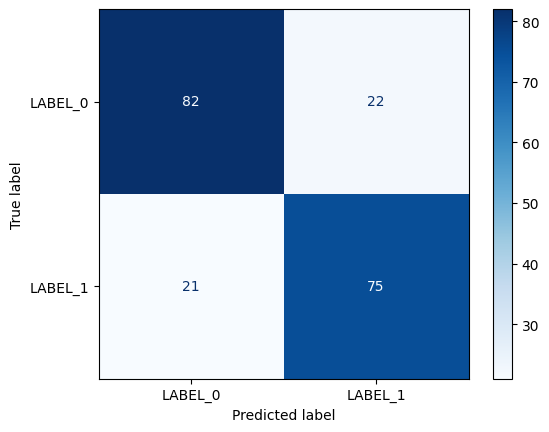

              precision    recall  f1-score   support

    negative       0.80      0.79      0.79       104
    positive       0.77      0.78      0.78        96

    accuracy                           0.79       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.79      0.79      0.79       200



In [2]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Reuse: `trainer` and `small_test` from Day 2
predictions = trainer.predict(small_test)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.config.id2label.values())
disp.plot(cmap="Blues")
plt.show()

# Detailed report
print(classification_report(y_true, y_pred, target_names=["negative","positive"]))


1) Core (10–15 min)
Task: Plot the confusion matrix and interpret which class the model struggles with most.

Struggles slightly more with positives

2) Practice (10–15 min)
Task: Print the 10 most confidently wrong predictions.

In [4]:
# --- Practice: 10 most confidently wrong predictions (fixed) ---
import numpy as np
import torch

pred_out = trainer.predict(small_test)
logits = torch.tensor(pred_out.predictions)
probs = torch.softmax(logits, dim=1).numpy()

y_true = pred_out.label_ids
y_pred = probs.argmax(axis=1)
pred_conf = probs[np.arange(len(y_pred)), y_pred]

wrong = np.where(y_pred != y_true)[0]
# Cast to Python ints to avoid Dataset indexing error
wrong = [int(i) for i in wrong]
top_wrong = sorted(wrong, key=lambda i: pred_conf[i], reverse=True)[:10]

label_names = ["negative", "positive"]

for rank, idx in enumerate(top_wrong, 1):
    ex = small_test[int(idx)]
    ids = ex["input_ids"]
    # convert tensor -> list for decode
    if isinstance(ids, torch.Tensor):
        ids = ids.tolist()
    text = tokenizer.decode(ids, skip_special_tokens=True)
    text = " ".join(text.split())[:500]

    print(f"\n#{rank}")
    print(f"True: {label_names[int(y_true[idx])]} | "
          f"Pred: {label_names[int(y_pred[idx])]} | "
          f"Pred prob: {pred_conf[idx]:.3f} | Probs: {probs[idx]}")
    print(f"Text: {text}")


c:\AI-Mastery\venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



#1
True: positive | Pred: negative | Pred prob: 0.778 | Probs: [0.77770597 0.22229405]
Text: this was one of the few shows that my wife and i agreed on watching. i was upset to hear that it was canceled, especially because i didn ' t realize the ratings were so poor. as far as i knew it was doing very well with a lot of viewers. almost all my friends and most of the people i spoke to watched the show. now we are stuck watching either crappy shows or dvd ' s. how bad was the show doing? does anyone know the real results of the shows viewings? i know that when it went to thursdays, it was

#2
True: positive | Pred: negative | Pred prob: 0.770 | Probs: [0.7700574  0.22994255]
Text: it is to typical of people complaining about something when they no nothing about it... so this is about a gay man falling for a straight women. first of all... this is a true story so you cant say its not believable second its written by a gay man so the whole thing about this being against the gays are just 

3) Stretch (optional, 10–15 min)
Task: Compute ROC-AUC.

In [ ]:
from sklearn.metrics import roc_auc_score
probs = predictions.predictions[:,1]
auc = roc_auc_score(y_true, probs)
print("ROC-AUC:", auc)     

"""
An ROC AUC (Receiver Operating Characteristic, Area Under the Curve) is a performance 
metric for binary classification models, visually represented by a graph showing the 
true positive rate (TPR) against the false positive rate (FPR) at various classification 
thresholds
"""


ROC-AUC: 0.8734975961538461


Mini-Challenge (≤40 min)

Task: Write a short error analysis:

Identify 3 misclassified examples.

Explain why the model might have failed (sarcasm, mixed sentiment, rare words).

Suggest one improvement (e.g., more data, domain-specific fine-tuning, parameter-efficient tuning).

Acceptance Criteria: Clear confusion matrix plot + at least 3 concrete examples of errors with reasons.

Error Analysis

Example 1

True: Positive | Pred: Negative

Text: “this was one of the few shows that my wife and i agreed on watching … upset to hear that it was canceled … almost all my friends … watched the show.”

Reason for failure: The review mixes positive sentiment (“agreed on watching”, “doing very well”) with negative framing (“upset”, “canceled”). The model may have latched onto negative words.

Improvement: More data with mixed sentiment examples or fine-tuning on domain-specific TV reviews.

Example 2

True: Positive | Pred: Negative

Text: “it is to typical of people complaining … personally i think this was the best love story i’ve ever seen.”

Reason for failure: Early negative phrasing (“complaining”, “stupid”) misleads the model before the clear positive opinion at the end.

Improvement: Longer context modeling or training with contrastive sentiment (reviews with both criticism + praise).

Example 3

True: Negative | Pred: Positive

Text: “i used to always love the bill … but lately … turned into an emotional soap … changed a lot from being amazing to average.”

Reason for failure: The review starts very positively before switching to criticism. The model likely overweighed the early positive cues.

Improvement: Better handling of shifted sentiment across long texts, possibly by segment-level classification.

General Suggestions

Collect more sarcasm / mixed sentiment samples.

Fine-tune with domain-specific datasets (e.g., TV/movie reviews).

Try parameter-efficient tuning (LoRA/adapters) for faster improvement.

Notes / Key Takeaways

Accuracy alone hides weaknesses.

Precision/recall/F1 balance matters, depending on use case.

Confusion matrix = quick snapshot of strengths/weaknesses.

Error analysis gives actionable next steps.

Evaluation is iterative — refine model after spotting weak spots.

Reflection

When would you prioritize recall over precision in a real-world app?

What patterns in errors might suggest data issues vs model issues?

When would you prioritize recall over precision in a real-world app?

When missing a positive case is more costly than raising false alarms.

Examples: medical diagnosis (better to flag all possible cancer cases, even if some are false positives), fraud detection, or safety alerts.

What patterns in errors might suggest data issues vs model issues?

Data issues: Errors cluster around rare words, mislabeled samples, or specific subgroups → suggests poor or unbalanced training data.

Model issues: Errors occur systematically (e.g., always misclassifies mixed sentiment, sarcasm, or long texts) → suggests limitations in model architecture or capacity.